In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
n = 5000
X = rng.uniform(-1, 1, size=n)
Z = rng.exponential(1.0, size=n)
Y = X + Z

In [2]:
a_grid = np.linspace(0, 2.5, 2501)
R_sq_hat = np.array([np.mean((Y - (X + a))**2) for a in a_grid])
R_abs_hat = np.array([np.mean(np.abs(Y - (X + a))) for a in a_grid])

a_sq_hat = a_grid[np.argmin(R_sq_hat)]
a_abs_hat = a_grid[np.argmin(R_abs_hat)]

print("Empirical minimizer, squared loss:", a_sq_hat)
print("Empirical minimizer, absolute loss:", a_abs_hat)
print("Theoretical minimizer, squared loss: 1")
print("Theoretical minimizer, absolute loss:", np.log(2))

Empirical minimizer, squared loss: 1.0110000000000001
Empirical minimizer, absolute loss: 0.706
Theoretical minimizer, squared loss: 1
Theoretical minimizer, absolute loss: 0.6931471805599453


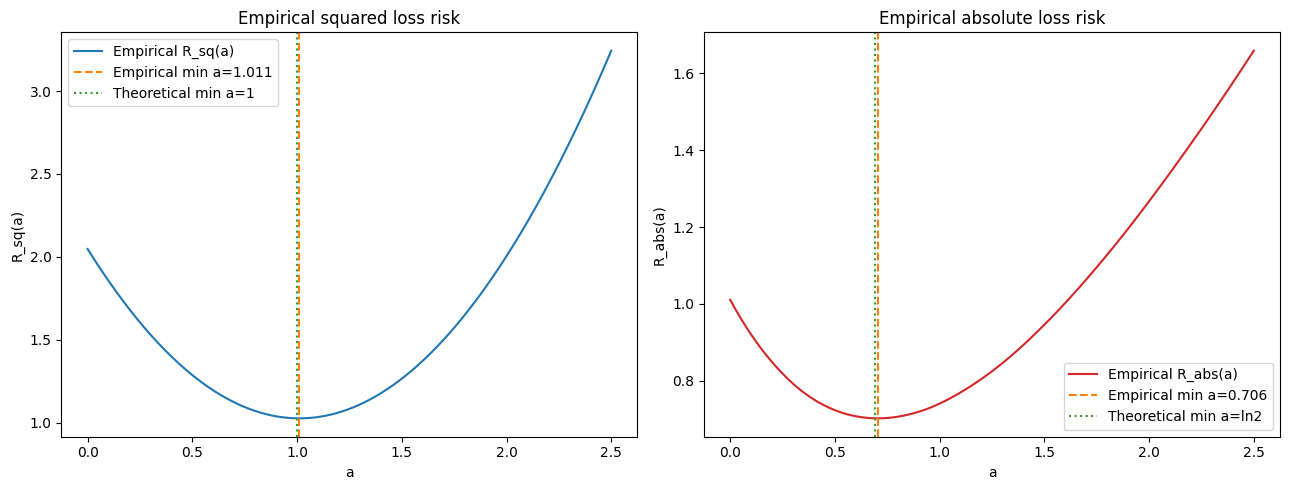

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(a_grid, R_sq_hat, label="Empirical R_sq(a)")
axes[0].axvline(a_sq_hat, color="tab:orange", linestyle="--", label=f"Empirical min a={a_sq_hat:.3f}")
axes[0].axvline(1.0, color="tab:green", linestyle=":", label="Theoretical min a=1")
axes[0].set_xlabel("a")
axes[0].set_ylabel("R_sq(a)")
axes[0].set_title("Empirical squared loss risk")
axes[0].legend()

axes[1].plot(a_grid, R_abs_hat, label="Empirical R_abs(a)", color="tab:red")
axes[1].axvline(a_abs_hat, color="tab:orange", linestyle="--", label=f"Empirical min a={a_abs_hat:.3f}")
axes[1].axvline(np.log(2), color="tab:green", linestyle=":", label="Theoretical min a=ln2")
axes[1].set_xlabel("a")
axes[1].set_ylabel("R_abs(a)")
axes[1].set_title("Empirical absolute loss risk")
axes[1].legend()

plt.tight_layout()
plt.show()

The empirical minimizer under squared loss came out to approximately 1.011, closely matching
the theoretical minimizer a = 1 derived in part 4(a), which in turn equals the intercept of the
Bayes predictor for squared loss from part 3(a), f*(x) = x + 1.

The empirical minimizer under absolute loss came out to approximately 0.706, closely matching
the theoretical minimizer a = ln 2 ≈ 0.6931, which equals the intercept of the Bayes predictor
for absolute loss from part 3(b), f*(x) = x + ln 2.

Both matches confirm the theory: the family f_a(x) = x + a was constructed with the correct
slope on x, so optimizing a within this family recovers the true, unconstrained Bayes predictor
rather than merely approximating it. The small gaps (about 0.011 and 0.013 respectively) are
sampling noise from using a finite sample of n = 5000, and would shrink further with a larger n.

- GORIOLA-OBAFEMI BABATUNDE SUKAMI
MSc. Applied Mathematics & Informatics
Machine Learning - Mathematical Basis